## Analisi grafica titanic

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
def disegnaGrafico(x_name, y_name, data, cat_name, ax):
    lista = data[cat_name].unique()
    if x_name == y_name:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.hist(selected_data[x_name], alpha = 0.5, bins = 15, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel("Numero di casi")
    else:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.scatter(selected_data[x_name], selected_data[y_name], alpha = 0.5, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
    ax.legend(labels = ["deceduti", "sopravvissuti"])
    ax.grid()

In [51]:
def analisiGrafica(data, cat_name):
    nomi_colonne = [col for col in data.columns if col != cat_name]
    
    n_vars = len(nomi_colonne)
    fig, axs = plt.subplots(nrows=n_vars, ncols=n_vars, figsize=(30, 30))
    
    for i, var1 in enumerate(nomi_colonne):
        for j, var2 in enumerate(nomi_colonne):
            disegnaGrafico(var1, var2, data, cat_name, axs[i, j])

    plt.savefig("titanic.pdf")
    plt.show()

In [52]:
dataframe = pd.read_csv("./titanic.csv")
dataframe

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [53]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [54]:
dataframe.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

In [55]:
dataframe.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [56]:
#Cambio da sesso in stringa a sesso in numeri
arraySesso = np.array(dataframe["Sex"])
array_Boolean_sex_male = arraySesso == "male"
risultato = np.zeros(arraySesso.shape)
risultato[array_Boolean_sex_male] = 1
print(risultato)

#Modo più veloce:
"""
"""

[1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1.
 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1.
 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1.
 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0.
 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0.
 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1.
 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1.
 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0.

'\n'

In [57]:
dataframe["SexNumber"] = risultato
dataframe.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,SexNumber
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1.0
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,0.0
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0.0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,0.0
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,1.0


In [58]:
cols = ['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare', 'SexNumber']
selected_data = dataframe[cols].dropna()
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Age                      887 non-null    float64
 3   Siblings/Spouses Aboard  887 non-null    int64  
 4   Parents/Children Aboard  887 non-null    int64  
 5   Fare                     887 non-null    float64
 6   SexNumber                887 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 48.6 KB


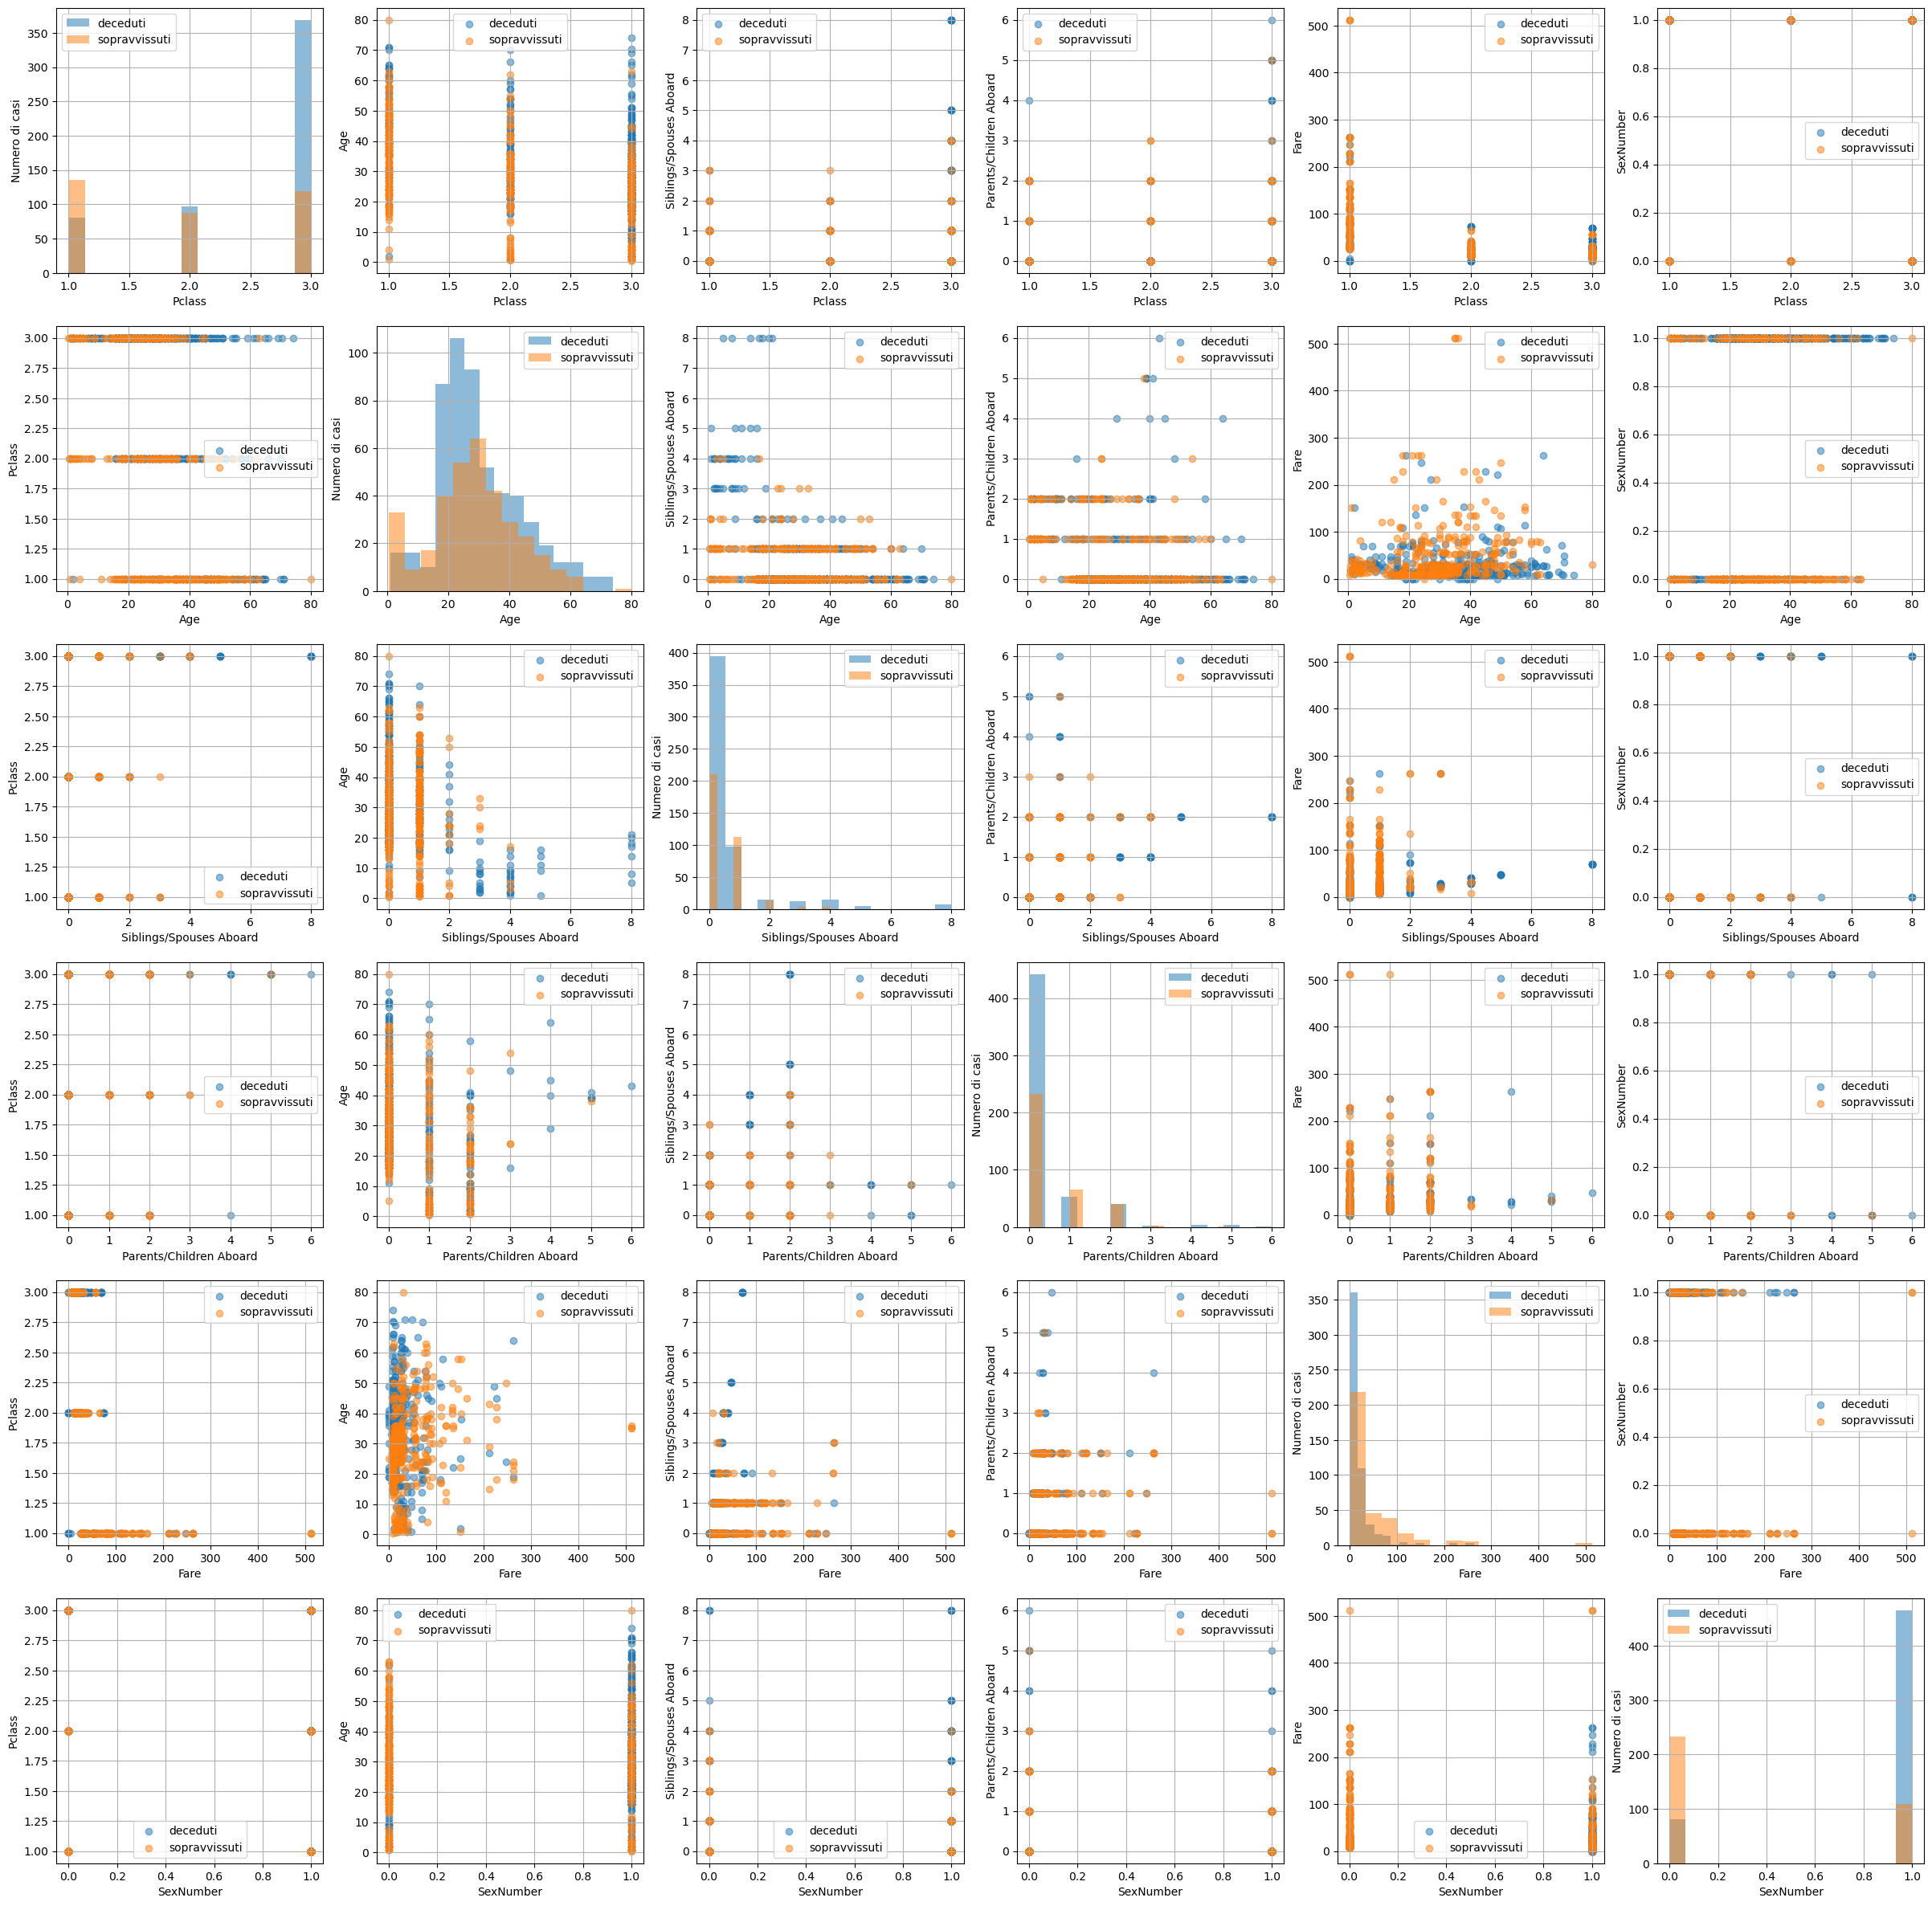

In [59]:
analisiGrafica(selected_data, "Survived")

In [60]:
# Voglio considerare i bambini (Tutte le persone tra 0 e 10 anni)

In [61]:
dataframe[dataframe.Age < 10]

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,SexNumber
7,0,3,Master. Gosta Leonard Palsson,male,2.00,3,1,21.0750,1.0
10,1,3,Miss. Marguerite Rut Sandstrom,female,4.00,1,1,16.7000,0.0
16,0,3,Master. Eugene Rice,male,2.00,4,1,29.1250,1.0
24,0,3,Miss. Torborg Danira Palsson,female,8.00,3,1,21.0750,0.0
42,1,2,Miss. Simonne Marie Anne Andree Laroche,female,3.00,1,2,41.5792,0.0
...,...,...,...,...,...,...,...,...,...
827,1,2,Master. George Sibley Richards,male,0.83,1,1,18.7500,1.0
846,0,3,Master. Sigvard Harald Elias Andersson,male,4.00,4,2,31.2750,1.0
848,0,3,Miss. Nourelain Boulos,female,9.00,1,1,15.2458,0.0
865,1,3,Master. Harold Theodor Johnson,male,4.00,1,1,11.1333,1.0


In [62]:
dataframe[dataframe.Age < 10]['Survived'].value_counts()

Survived
1    41
0    30
Name: count, dtype: int64

In [63]:
#Per ogni classe numero di deceduti e sopravvissuti

In [64]:
dataframe.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           368
        1           119
Name: count, dtype: int64

In [65]:
#Età media dei sopravvissuti per classe
dataframe[dataframe['Survived'] == 1].groupby('Pclass')['Age'].mean()

Pclass
1    35.962647
2    26.170460
3    21.411092
Name: Age, dtype: float64

In [66]:
#Prezzo medio del biglietto per classe
dataframe.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.707707
Name: Fare, dtype: float64

In [67]:
#Numero di sopravvissuti e deceduti per chi ha un compagno o fratello...

In [68]:
dataframe[dataframe['Siblings/Spouses Aboard'] > 1]['Survived'].value_counts()

Survived
0    54
1    20
Name: count, dtype: int64